NIM Mahasiswa: 24146030
Memulai pemuatan dataset...
Total Citra Berhasil Dimuat: 3670
Jumlah Data Latih (80%): 2936
Jumlah Data Uji (20%): 734
Sedang melatih model MLP...
Pelatihan Selesai!

=== Classification Report ===
              precision    recall  f1-score   support

       daisy     0.3816    0.2302    0.2871       126
   dandelion     0.4336    0.6167    0.5092       180
       roses     0.4505    0.3906    0.4184       128
  sunflowers     0.6463    0.3786    0.4775       140
      tulips     0.3493    0.4562    0.3957       160

    accuracy                         0.4305       734
   macro avg     0.4522    0.4145    0.4176       734
weighted avg     0.4498    0.4305    0.4244       734



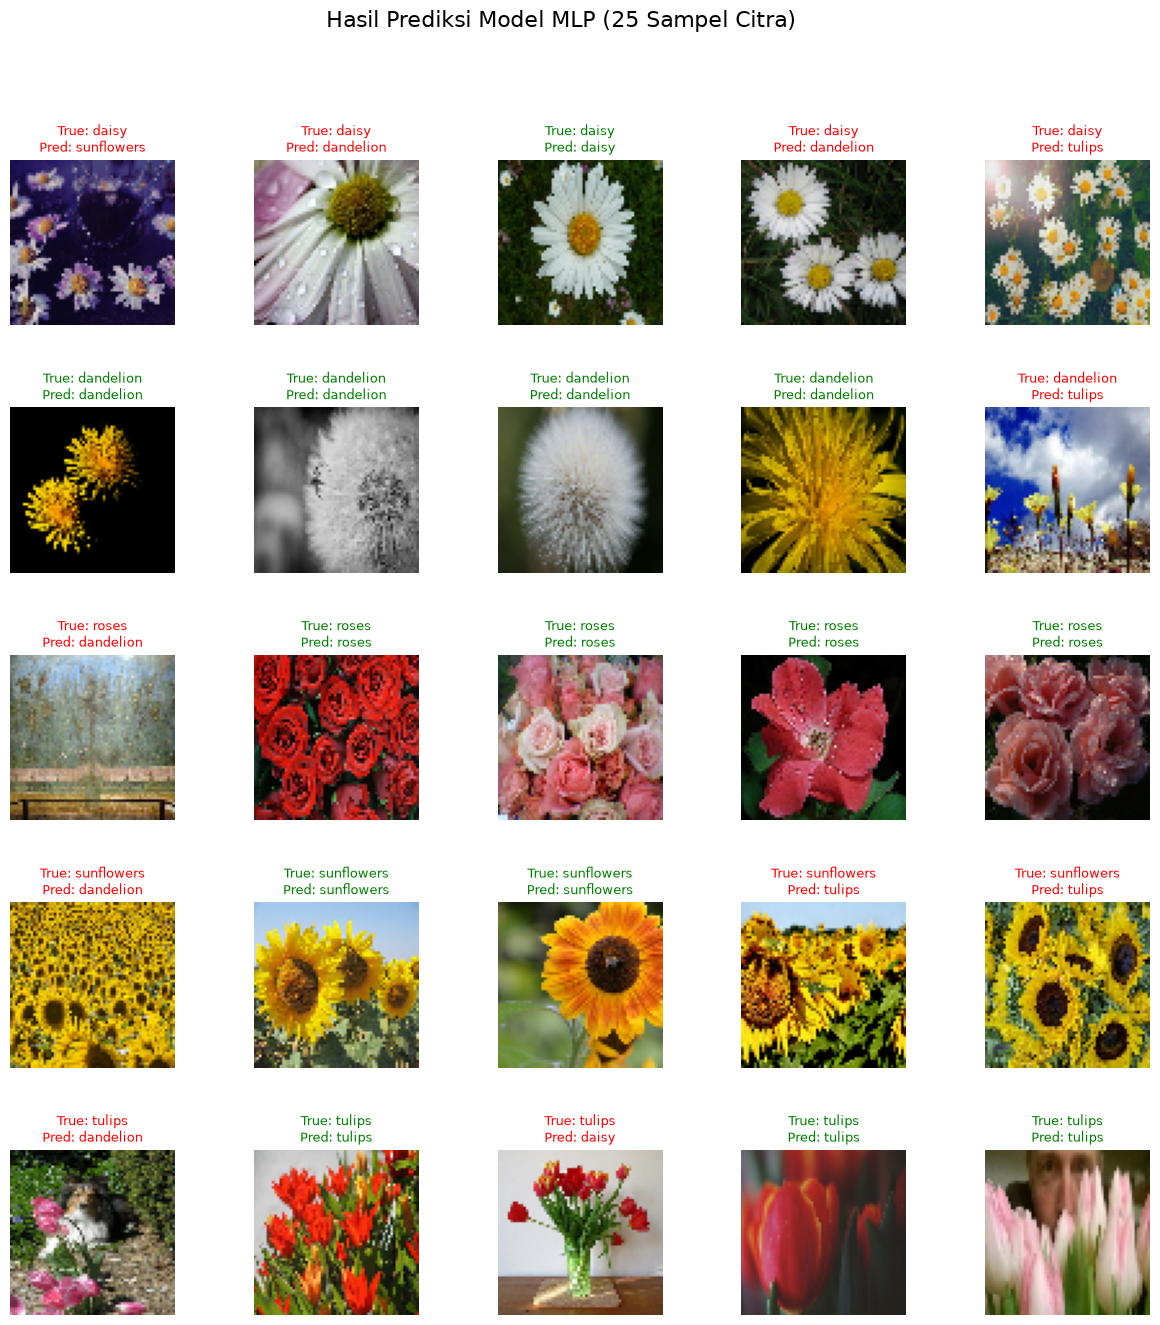

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

# Mengatur NIM sebagai random_state
NIM = 24146030
print(f"NIM Mahasiswa: {NIM}")

DATASET_DIR = "flowers"
CLASSES = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
IMG_SIZE = 64

X = []
y = []
raw_images = []

print("Memulai pemuatan dataset...")
for label_idx, class_name in enumerate(CLASSES):
    class_dir = os.path.join(DATASET_DIR, class_name)
    if not os.path.exists(class_dir):
        print(f"Peringatan: Folder {class_dir} tidak ditemukan!")
        continue
    
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        # Ubah BGR ke RGB & Resize ke 64x64
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
        
        # Normalisasi ke [0, 1] dan Flatten ke 1D Array
        feature_vector = (img_resized / 255.0).flatten()
        
        X.append(feature_vector)
        y.append(label_idx)
        raw_images.append(img_resized)

X = np.array(X)
y = np.array(y)
raw_images = np.array(raw_images)

print(f"Total Citra Berhasil Dimuat: {len(X)}")

# Bagi data 80% Training dan 20% Testing menggunakan NIM sebagai random_state
X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
    X, y, raw_images, test_size=0.2, random_state=NIM, stratify=y
)

print(f"Jumlah Data Latih (80%): {len(X_train)}")
print(f"Jumlah Data Uji (20%): {len(X_test)}")

# Pelatihan Model MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=NIM
)

print("Sedang melatih model MLP...")
mlp.fit(X_train, y_train)
print("Pelatihan Selesai!")

# Evaluasi Performance
y_pred = mlp.predict(X_test)
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=4))

# Visualisasi Prediksi 25 Gambar (Grid 5x5)
fig, axes = plt.subplots(5, 5, figsize=(15, 15))
plt.subplots_adjust(wspace=0.3, hspace=0.5)

np.random.seed(NIM) # Mengunci acakan sampel dengan NIM

for i, class_idx in enumerate(range(5)):
    indices = np.where(y_test == class_idx)[0]
    
    # Memilih 5 sampel acak dari masing-masing kelas (Total 25)
    if len(indices) >= 5:
        selected_indices = np.random.choice(indices, 5, replace=False)
    else:
        selected_indices = np.random.choice(len(y_test), 5, replace=False)
    
    for j, idx in enumerate(selected_indices):
        ax = axes[i, j]
        ax.imshow(img_test[idx])
        
        actual_label = CLASSES[y_test[idx]]
        pred_label = CLASSES[y_pred[idx]]
        
        color = 'green' if actual_label == pred_label else 'red'
        ax.set_title(f"True: {actual_label}\nPred: {pred_label}", color=color, fontsize=9)
        ax.axis('off')

plt.suptitle("Hasil Prediksi Model MLP (25 Sampel Citra)", fontsize=16)

plt.savefig("grid_25_samples.png", bbox_inches='tight', dpi=300)

plt.show()